000


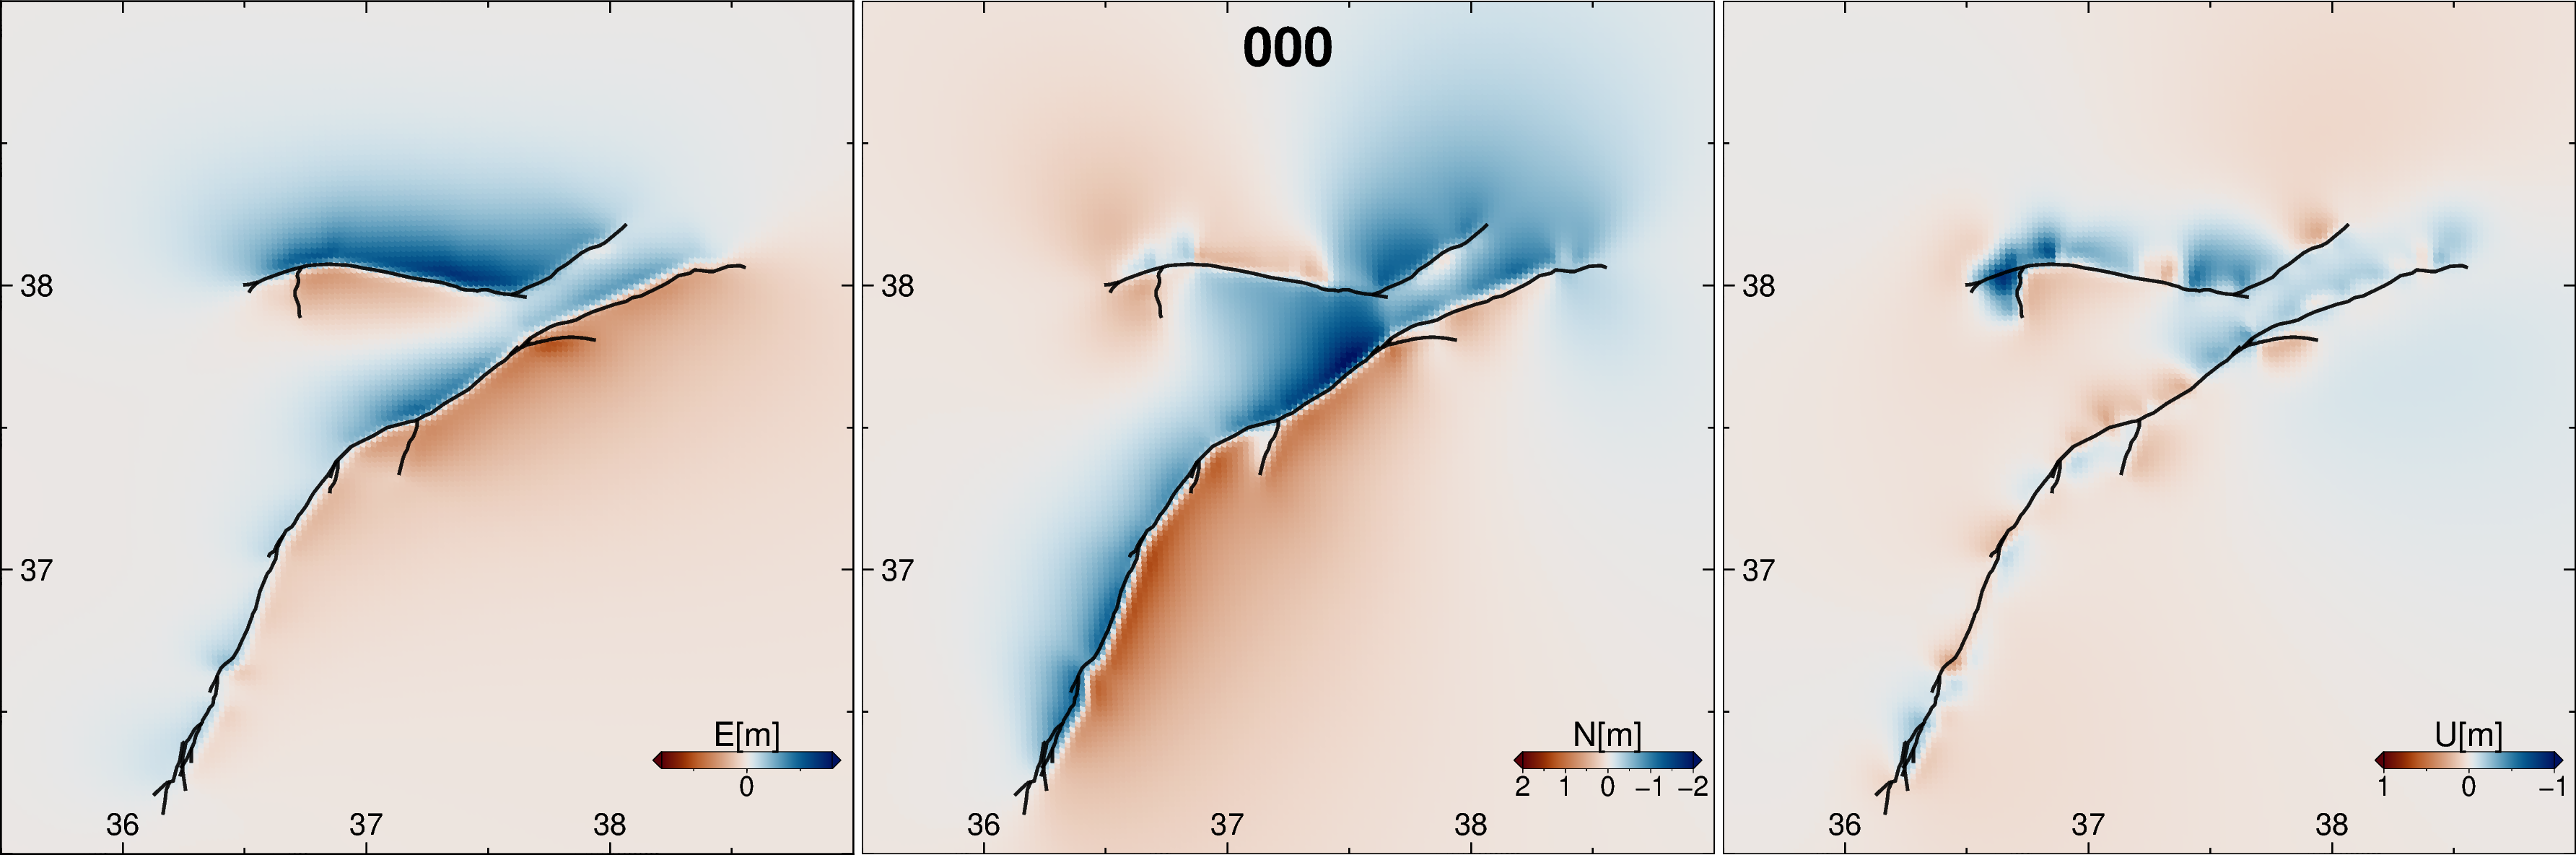

In [4]:
import pandas as pd
import pygmt
import xarray as xr
import os
import math
import numpy as np


# -----------------------------------------------------------------------------
# Region
lonmin_lamb = 1  # degrees East
lonmax_lamb = 80
latmin_lamb = 25
latmax_lamb = 60
RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]

region_TR= [35.5, 39, 36, 39] 
# region_TR = [33, 43, 33, 42]
fault_file=f'/scratch/eemne/github/3D_InSAR_dataset/simple_fault/simple_fault_2023-2-14.shp'


# dem_file='earth_relief_fullAHB_30s.nc'
# # Upload data
# batchdir = '/scratch/eemne/'
# dem = os.path.join(batchdir, dem_file)
# dem_resolution='30s'
# GEMS_dir='/scratch/eemne/GEMS'
# fault_file=f'{GEMS_dir}/GEM_NAEF.shp'

# #####
# # DEM downloading
# if not os.path.exists(dem):
#     print('DEM is downloading please wait! After downloading, the process will be faster!')
#     try:
#         # Download the earth relief data and save it to a file
#         grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
#         # Saving the grid to a NetCDF file
#         grid.to_netcdf(dem)
#         print(f"Data successfully downloaded and saved to {dem}")
#     except Exception as e:
#         print(f"An error occurred: {e}")
# else:
#     print(f'DEM already exists!')
for i in range(0, 1):  # 1 to 100 inclusive
    print(f"{i:03d}")
    
    fig = pygmt.Figure()
    pygmt.config(
        MAP_FRAME_TYPE="plain",
        FONT_ANNOT_PRIMARY="25p,Helvetica,black",   # longitude ticks
        FONT_LABEL="30p,Helvetica,black",       # axis labels
        FORMAT_GEO_MAP='D',
        MAP_FRAME_PEN="0.5p,black"  # 2-point thick black frame line
    )

    ####First
    fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
    ###colorbar
    pygmt.makecpt(cmap='vik', series=[-4,4, 0.01], continuous=True, reverse=False)

    # PLOT asc_file
    # First layer: with shading (but no transparency)
    #######---------second----------#######
    # workdir='/scratch/eemne/github/relax1/examples/2023_kahramanmaras_for_KFGTI-08102025/coseismic_for_KFGTI_fialko_120'
    workdir='/scratch/eemne/github/3D_InSAR_dataset/relax_models/2.viscoelastic/2layer_maxwell/2layer_maxwell_t1-10000-40000_t2-17-20/2layer_maxwell_t1-16000m_eta-1e18p5'
    # workdir='/scratch/eemne/github/3D_InSAR_dataset/relax_models/2.viscoelastic/2layer_maxwell/2layer_maxwell_t1-10000-40000_t2-17-20/2layer_maxwell_t1-16000m_eta-1e18p5'
    fig.plot(data=f'{workdir}/{i:03d}-geo-east.xyz', style="c0.1c", fill="+z", cmap=True)
    # #plot faulta
    fig.plot(data=fault_file, pen="1p,black", transparency=10)

    ###colorbar
    fig.colorbar(
        frame='a5f2.5+lE[m]',  # Label for the color bar
        cmap=True,
        position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e+reverse",  # Adjust position
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )

    # ###lastbasemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="10p,Helvetica,black")
    fig.basemap(projection="X10c", region=region_TR, frame=["x1f0.5","y1f0.5",'WSne'])


    #####--------second----------#######

    fig.shift_origin(xshift="10.1c", yshift="0c")
    fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
    ###colorbar
    pygmt.makecpt(cmap='vik', series=[-2,2, 0.01], continuous=True, reverse=False)

    # PLOT asc_file
    # First layer: with shading (but no transparency)
    #######---------second----------#######

    fig.plot(data=f'{workdir}/{i:03d}-geo-north.xyz', style="c0.1c", fill="+z", cmap=True)
    # #plot faults
    fig.plot(data=fault_file, pen="1p,black", transparency=10)
    
    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT="25p,Helvetica,black")
    fig.colorbar(
        frame='a1f0.5+lN[m]',  # Label for the color bar
        cmap=True,
        position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e+reverse",  # Adjust position
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )
    
    # Add top-center text label (e.g., "001", "002", ...)
    fig.text(
    text=f"{i:03d}",        # your dynamic index label
    position="TC",          # T = top, C = center
    font="18p,Helvetica-Bold,black",  # font size/style
    offset="0c/-0.3c"        # slight vertical offset down from top edge
    )

    # ###lastbasemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT_PRIMARY="10p,Helvetica,black")
    fig.basemap(projection="X10c", region=region_TR, frame=["x1f0.5","y1f0.5",'WSne'])


    #####--------third----------#######
    fig.shift_origin(xshift="10.1c", yshift="0c")
    fig.basemap(projection="X10c", region=region_TR, frame=['WSne'])
    ###colorbar
    pygmt.makecpt(cmap='vik', series=[-1,1, 0.01], continuous=True, reverse=False)

    # PLOT asc_file
    # First layer: with shading (but no transparency)

    fig.plot(data=f'{workdir}/{i:03d}-geo-up.xyz', style="c0.1c", fill="+z", cmap=True)
    # #plot faults
    fig.plot(data=fault_file, pen="1p,black", transparency=10)
    
    ###colorbar
    pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT="25p,Helvetica,black")
    fig.colorbar(
        frame='a1f0.5+lU[m]',  # Label for the color bar
        cmap=True,
        position="JBC+o3.75c/-1.2c+w2c/0.20c+ml+h+e+reverse",  # Adjust position
        # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
        # box="+gwhite@50"
    )


    # ###lastbasemap
    pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT_PRIMARY="10p,Helvetica,black")
    fig.basemap(projection="X10c", region=region_TR, frame=["x1f0.5","y1f0.5",'WSne'])

    fig.show()